# Carbon Mapper products

How to consume Carbon Mapper data at every product level via the
georeader reader subpackage. One section per resource type, each
showing the typed model, the asset wrapper, and a worked example
with inline plots:

| § | Resource | Wrapper | Headline asset |
|---|---|---|---|
| 1 | **Plume** — one detection | `CMRawPlume` (typed metadata) | catalog dict + asset URLs |
| 2 | **Image** — per-plume products | `CMPlumeImage` (this PR's headline) | mask, concentrations, ime, rgb, outline |
| 3 | **Tile** — L2B scene | `CMImageRaster` | cmf retrieval + RGB sibling |
| 4 | **Source** — DBSCAN cluster | `CMSource` | source-aggregated plume stats |

**CH4 only in this notebook.** The reader is gas-agnostic
internally, but query helpers are typed `Literal["CH4"]` for now;
CO2 lands in a follow-up.

Companion: [`api_explore.ipynb`](api_explore.ipynb) — the typed
query layer in depth (REST + STAC surfaces, filter map, exception
hierarchy).


## Install

```
pip install 'georeader-spaceml[carbonmapper]'
```

Includes `pydantic`, `requests`, and the standard rasterio /
shapely dependencies. The wrappers go through
`georeader.RasterioReader` for the actual GeoTIFF I/O — no
extras beyond the base `[carbonmapper]` extra.


## Setup

`CarbonMapperConfig.load()` resolves a Bearer token from env
(`CARBONMAPPER_TOKEN`, or `CARBONMAPPER_EMAIL`+`PASSWORD`) or one
of the standard config-file paths — see
[`api_explore.ipynb#authentication`](api_explore.ipynb#authentication).

Carbon Mapper's STAC asset URLs are also gated by the same token,
so we push it into GDAL's curl session here. `RasterioReader`
goes through `rasterio` → GDAL → libcurl, which reads the env var.


In [1]:
import os

from georeader.readers.carbonmapper import (
    CarbonMapperConfig,
    CMCollectionSpec,
    CMProductFamily,
    Gas,
    Instrument,
    api_queries,
)

# --- 429-resilient HTTP -----------------------------------------------
# CarbonMapper rate-limits per account. Notebook re-executions fire
# dozens of catalog probes back-to-back and can trip the per-minute cap.
# Mount a retry-aware adapter on a shared Session and re-bind the
# `requests` module shortcuts to route through it — so every HTTP call
# in this kernel (including ones inside georeader's own .download
# helpers) gets automatic 429 backoff honouring `Retry-After`, plus
# exponential backoff for transient 5xx.
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

_cm_session = requests.Session()
_cm_session.mount("https://", HTTPAdapter(max_retries=Retry(
    total=8,
    backoff_factor=2.0,           # 2, 4, 8, 16, 32, 64 s
    status_forcelist=(429, 500, 502, 503, 504),
    respect_retry_after_header=True,
    allowed_methods=frozenset(["GET", "POST"]),
)))
requests.get = _cm_session.get
requests.post = _cm_session.post
requests.request = _cm_session.request

TOKEN = CarbonMapperConfig.load().refresh_access_token()

# RasterioReader streams over GDAL/libcurl. Push the token in once.
os.environ["GDAL_HTTP_HEADERS"] = f"Authorization: Bearer {TOKEN}"
os.environ["CPL_VSIL_CURL_ALLOWED_EXTENSIONS"] = ".tif,.TIF"
# Retry on transient HTTP failures (5xx + 429) — the CarbonMapper
# CDN occasionally rate-limits tight read sequences. GDAL's built-in
# retry hides those from rasterio.
os.environ["GDAL_HTTP_MAX_RETRY"] = "5"
os.environ["GDAL_HTTP_RETRY_DELAY"] = "3"   # seconds (exponential)

# Protagonist plume — March 31, 2026. Its L3A was re-versioned to
# v3d while the L2B parent still serves at v3c — the exact case the
# reader's probe-first resolution handles (record's version tried
# first, default candidates as backup). 1954 kg/h emission — the
# strongest plume of this scene.
PLUME_ID = "tan20260331t181625c77s4001-D"
print(f"plume_id = {PLUME_ID}")

# CMCollectionSpec composes every collection id from the
# (gas, cmf_type, version) triple — resolved per plume from its own
# record, never guessed from hardcoded version lists.
spec = CMCollectionSpec(version="v3d")
for fam in CMProductFamily:
    print(f"  {fam.name:8s} → {spec.collection_id(fam)}")


plume_id = tan20260331t181625c77s4001-D
  L3A_VIS  → l3a-vis-ch4-mfa-v3d
  L3A_IME  → l3a-ime-ch4-mfa-v3d
  L2B      → l2b-ch4-mfa-v3d
  L2B_RGB  → l2b-rgb-v3d


## Products inventory — what's reachable per plume

Static reference — no API calls. Ground truth verified against the
live API in [`api_audit_2026-07.md`](api_audit_2026-07.md).

Every product below is a first-class descriptor in
`georeader.readers.carbonmapper.products` — construction takes an
explicit `products=` selection, so you fetch exactly what you ask
for (defaults reproduce the classic 7-asset bundle).

### Per-plume assets (L3A vis + ime collections)

12 reachable assets per CH4 plume. The 7 GeoTIFF/GeoJSON products
are in `DEFAULT_PLUME_PRODUCTS` and map to lazy properties; the 5
PNG quicklooks are decimated thumbnails without georeferencing —
modelled as `CMQuicklookProduct` (open → raw `bytes`) and included
only via `ALL_PLUME_PRODUCTS` or an explicit selection.

| Asset | Format | What it is | Product / property |
|---|---|---|---|
| `plume.tif` | GeoTIFF (RGBA) | Mask raster — band 4 alpha = broader plume mask | `P.PLUME_TIF` → **`mask`** |
| `plume-concentrations.tif` | GeoTIFF (1-band) | CH4 column density crop (full per-plume window) | `P.PLUME_CONCENTRATIONS` → **`concentrations`** |
| `ime-cmf-concentrations.tif` | GeoTIFF (1-band) | IME-clipped column density (only mask-significant pixels) | `P.IME_CONCENTRATIONS` → **`ime_concentrations`** |
| `ime-cmf-mask.tif` | GeoTIFF (1-band) | IME-significance binary mask (subset of `mask`) | `P.IME_MASK` → **`ime_mask`** |
| `rgb.tif` | GeoTIFF (3-band) | True-colour context (widest extent of all per-plume assets) | `P.RGB_TIF` → **`rgb`** |
| `plume-outline.geojson` | GeoJSON | Broader plume polygon (canonical) | `P.PLUME_OUTLINE` → **`outline`** |
| `ime-cmf-outline.geojson` | GeoJSON | Tighter IME-significant polygon | `P.IME_OUTLINE` → **`ime_outline`** |
| `plume.png` | PNG | Decimated viz of `plume.tif` | `P.PLUME_PNG` _(quicklook, opt-in)_ |
| `plume-rgb.png` | PNG | Plume mask overlaid on RGB | `P.PLUME_RGB_PNG` _(quicklook, opt-in)_ |
| `rgb.png` | PNG | Decimated viz of `rgb.tif` | `P.RGB_PNG` _(quicklook, opt-in)_ |
| `ime-cmf-concentrations.png` | PNG | Decimated viz | `P.IME_CONCENTRATIONS_PNG` _(quicklook, opt-in)_ |
| `ime-cmf-mask.png` | PNG | Decimated viz | `P.IME_MASK_PNG` _(quicklook, opt-in)_ |

For a wider scene-level concentration view, use the L2B
`CMImageRaster.cmf` from the parent tile (§ 3) — there is **no**
wider concentration product at the plume level.

### Native extents (verified for one v3a plume)

Each asset has a different native size — Carbon Mapper crops them
at different scales:

| Asset | Pixels | Approx. ground span |
|---|---|---|
| `plume.tif` / `rgb.tif` | 101 × 100 | 3030m × 3000m (widest — full context window) |
| `plume-concentrations.tif` | 41 × 48 | 1230m × 1440m (per-plume crop) |
| `ime-cmf-concentrations.tif` | 11 × 11 | 330m × 330m (IME-significant only — tightest) |
| PNG variants | 6×3 to 115×115 | n/a (decimated thumbnails) |

This asymmetry is why the §2.4 visualization locks all panels to
a common viewport (rgb dominates).

### Versioning — resolved per plume, never hardcoded

Carbon Mapper bumps `emission_version` per processing-software
release (`v3a` → `v3b` → `v3c` → `v3d` → …). Two facts from the
2026-07 audit shape how the reader handles this:

- **`/stac/collections` stops at `v3a`** (plumes 2023-10 →
  2025-12). Everything newer exists only in the asset-proxy
  namespace and is reachable via URL derivation from the plume
  record.
- **The record itself names its collections.** `CMCollectionSpec`
  parses the `(gas, cmf_type, version)` triple from the plume's
  own `plume_tif` URL (or its `gas`/`cmf_type`/`emission_version`
  fields) and composes all four collection ids — so the reader
  works for any future version without a code change. For the L2B
  parent, the record's version is probed first with older
  candidates as backup (L3A can be re-versioned ahead of the L2B —
  this notebook's protagonist is exactly that case).


## 1 · Plumes — typed metadata

`CMRawPlume` is the typed view of one Carbon Mapper detection. The
headline metric is `emission_auto` (kg/h); everything else
(emission uncertainty, wind, geometry, sector, instrument) is
ancillary.

Three derived properties bridge plumes to the other entities below:

- **`scene_id`** — `plume_id.rsplit('-', 1)[0]`, the parseable
  scene *name*. (The API's own `scene_id` field is an internal
  UUID — exposed as `scene_uuid`.) Use this to navigate from a
  plume to its parent tile (§3) without an HTTP round-trip.
- **`version`** — re-exposes `emission_version` (`"v3a"` … `"v3d"`).
- **`collection_spec`** — the resolved
  `(gas, cmf_type, version)` triple that names every collection
  this plume's assets live in. `CMPlumeImage` and the tile
  resolver use it so nothing version-specific is ever hardcoded.


In [2]:
plume = api_queries.get_plume(TOKEN, PLUME_ID)

print(f"plume_id        : {plume.plume_id}")
print(f"gas             : {plume.gas}")
print(f"instrument      : {plume.instrument}  → {plume.instrument_name}")
print(f"version         : {plume.version}")
print(f"collection_spec : {plume.collection_spec}")
print(f"scene_id        : {plume.scene_id}     ← derived (rsplit)")
print(f"scene_uuid      : {plume.scene_uuid}    ← API's internal UUID")
print(f"emission_auto   : {plume.emission_auto:>9.1f} kg/h")
print(f"wind (u, v)     : ({plume.wind_u:.2f}, {plume.wind_v:.2f}) m/s")
print(f"sector          : {plume.sector}")


plume_id        : tan20260331t181625c77s4001-D
gas             : CH4
instrument      : tan  → Tanager-1
version         : v3d
collection_spec : CMCollectionSpec(version='v3d', gas='ch4', cmf_type='mfa')
scene_id        : tan20260331t181625c77s4001     ← derived (rsplit)
scene_uuid      : 0589e686-c524-4c79-b5b5-c0af09c9f2b1    ← API's internal UUID
emission_auto   :    1953.9 kg/h
wind (u, v)     : (0.48, 4.72) m/s
sector          : 1B2


### 1.1 Enums for constrained value sets

Three `StrEnum`s expose Carbon Mapper's closed value sets. They
satisfy `str` so they're drop-in for any string parameter, but
typed checking + IDE autocomplete come for free.


In [3]:
print(f"Gas:        {[g.value for g in Gas]}")
print(f"Instrument: {[i.value for i in Instrument]}")
print()

# Instrument is case-insensitive on construction (the upstream API
# is mixed-case — `tan` lowercase, `GAO` uppercase — and `_missing_`
# normalises).
for variant in ("tan", "TAN", "Tan", "gao", "GAO"):
    print(f"  Instrument({variant!r:>5}) → {Instrument(variant)}")


Gas:        ['CH4', 'CO2']
Instrument: ['tan', 'emi', 'ang', 'av3', 'GAO']

  Instrument('tan') → tan
  Instrument('TAN') → tan
  Instrument('Tan') → tan
  Instrument('gao') → GAO
  Instrument('GAO') → GAO


### 1.2 `list_plumes` — typed, filterable, paginated

The default consumer surface for plume discovery. `gas` is typed
`Gas | Literal["CH4"]` so plain `gas="CH4"` calls keep
type-checking.


In [4]:
from datetime import datetime, timezone

# March 2026 Tanager CH4 detections across CONUS — same time
# window as the protagonist plume. Shows the L3A version split
# (v3c through 2026-02, v3d from 2026-03) on the `version` field.
plumes = api_queries.list_plumes(
    TOKEN,
    instruments=["tan"],
    datetime_min=datetime(2026, 3, 1, tzinfo=timezone.utc),
    datetime_max=datetime(2026, 3, 31, tzinfo=timezone.utc),
    gas=Gas.CH4,
    limit=20,
)
print(f"{len(plumes)} CH4 Tanager plumes (March 2026)\n")
for p in plumes[:5]:
    em = f"{p.emission_auto:>7.0f}" if p.emission_auto is not None else "      —"
    print(
        f"  {p.plume_id}  emission={em} kg/h  "
        f"sector={p.sector}  version={p.version}"
    )


20 CH4 Tanager plumes (March 2026)

  tan20260330t202535c84s4001-A  emission=    798 kg/h  sector=6A  version=v3c
  tan20260330t185628c23s4001-A  emission=      — kg/h  sector=1B2  version=v3c
  tan20260330t185628c23s4001-B  emission=      — kg/h  sector=1B2  version=v3c
  tan20260330t185628c23s4001-C  emission=    518 kg/h  sector=1B2  version=v3c
  tan20260330t185628c23s4001-D  emission=      — kg/h  sector=1B2  version=v3c


## 2 · Images — per-plume product bundle

`CMPlumeImage` wraps the per-plume L3A products you **select** as
lazy properties. The default selection (`DEFAULT_PLUME_PRODUCTS`)
is the classic 7-asset bundle:

| Property | Product | Type | Notes |
|---|---|---|---|
| `mask` | `P.PLUME_TIF` | `RasterioReader` (RGBA) | Band 4 alpha = broader plume mask |
| `concentrations` | `P.PLUME_CONCENTRATIONS` | `RasterioReader` | Per-plume column-density crop (full) |
| `ime_concentrations` | `P.IME_CONCENTRATIONS` | `RasterioReader` | IME-clipped column density — **the data CM integrated for `emission_auto`** |
| `ime_mask` | `P.IME_MASK` | `RasterioReader` | IME-significant binary mask — tighter subset of `mask` |
| `rgb` | `P.RGB_TIF` | `RasterioReader` | True-colour context (3-band) |
| `outline` | `P.PLUME_OUTLINE` | `shapely.MultiPolygon` | Broader plume polygon (canonical) |
| `ime_outline` | `P.IME_OUTLINE` | `shapely.MultiPolygon` | Tighter IME-significant polygon |

PNG quicklooks (`P.PLUME_PNG`, `P.PLUME_RGB_PNG`, `P.RGB_PNG`,
`P.IME_CONCENTRATIONS_PNG`, `P.IME_MASK_PNG`) are decimated
thumbnails for visualisation, not georeferenced data — select them
explicitly (or use `ALL_PLUME_PRODUCTS`) and open via
`img.product(...)`, which returns raw `bytes`.

**Key design choices:**

- **Explicit selection** — `products=` says exactly which assets
  the bundle exposes. Accessing a product you didn't select raises
  `CMProductNotSelected` instead of silently returning `None`.
- **Outline canonical** — `outline` fetches the GeoJSON; falls
  back to vectorising band-4 alpha (with a warning) only on fetch
  failure. `ime_outline` returns `None` rather than
  vectorising — the broader `outline` is the safety net.
- **Version-agnostic** — `from_plume_id` derives every asset URL
  from the record's own `plume_tif` collection segment via
  `CMCollectionSpec`. Works for v3a (STAC-resident), v3c/v3d
  (asset-proxy only), and any future bump — nothing hardcoded.
- **Lazy** — opening one product doesn't open the others. Each is
  cached after first access.

**No other concentration GeoTIFF exists at the plume level.** The
two above (`concentrations` + `ime_concentrations`) are it. For
a wider scene-level concentration view, use `CMImageRaster.cmf`
from the parent tile (see § 3).


### 2.1 Construction — three entry points

`from_plume_id` (one HTTP round-trip), `from_cmrawplume` (zero
HTTP if you already have the typed plume), and `from_stac_item`
(driving STAC search directly; v3a only).


In [5]:
from georeader.readers.carbonmapper import CMPlumeImage

# Option A — from a plume_id (one HTTP; any version, resolved from
# the record itself). Default selection = the 7-asset bundle.
img = CMPlumeImage.from_plume_id(PLUME_ID, token=TOKEN)
print(img)
print()
print(f"resolved spec: {img.spec}")


CMPlumeImage
  plume_id:       tan20260331t181625c77s4001-D
  assets present: ['plume.tif', 'plume-concentrations.tif', 'plume-outline.geojson', 'rgb.tif', 'ime-cmf-concentrations.tif', 'ime-cmf-mask.tif', 'ime-cmf-outline.geojson']
  spec:           CMCollectionSpec(version='v3d', gas='ch4', cmf_type='mfa')
  overview_level: full

resolved spec: CMCollectionSpec(version='v3d', gas='ch4', cmf_type='mfa')


### 2.1b Explicit product selection

The bundle exposes exactly the products you pass in `products=` —
descriptors from `georeader.readers.carbonmapper.products`. A
selective bundle derives fewer URLs, and any access outside the
selection raises `CMProductNotSelected` (no silent `None`s). The
generic accessor `img.product(P.X)` works for every kind —
including the PNG quicklooks, which have no dedicated property.


In [6]:
from georeader.readers.carbonmapper import CMProductNotSelected
from georeader.readers.carbonmapper import products as P

# The full registry — every product Carbon Mapper publishes.
print(f"{'product':28s} {'family':8s} description")
print("-" * 80)
for prod in P.ALL_PRODUCTS:
    print(f"  {prod.key:26s} {prod.family.value:8s} {prod.description[:44]}")

# A selective bundle: only the outline + the true-colour crop.
lean = CMPlumeImage.from_plume_id(
    PLUME_ID, token=TOKEN,
    products=(P.PLUME_OUTLINE, P.RGB_TIF),
)
print()
print(f"lean bundle URLs: {sorted(lean.urls)}")

# Accessing anything outside the selection fails loudly.
try:
    lean.concentrations
except CMProductNotSelected as exc:
    print(f"\nCMProductNotSelected: {exc}")


product                      family   description
--------------------------------------------------------------------------------
  plume.tif                  l3a-vis  RGBA visualisation with plume overlay; band-
  plume-concentrations.tif   l3a-vis  CH4 column density crop (ppm·m), thumbnail-g
  plume-outline.geojson      l3a-vis  Plume polygon (EPSG:4326) — the broader full
  rgb.tif                    l3a-vis  3-band uint8 true-colour crop of the plume w
  ime-cmf-concentrations.tif l3a-ime  IME-clipped CH4 column density (~11×11 px) —
  ime-cmf-mask.tif           l3a-ime  Binary mask of pixels contributing to emissi
  ime-cmf-outline.geojson    l3a-ime  IME-significance polygon (tighter than plume
  plume.png                  l3a-vis  Non-georeferenced quicklook of plume.tif
  rgb.png                    l3a-vis  Non-georeferenced quicklook of rgb.tif
  plume-rgb.png              l3a-vis  Non-georeferenced quicklook — plume overlaid
  ime-cmf-concentrations.png l3a-ime  Non-georefe

### 2.2 Properties — what's reachable

URL derivation already happened in `from_plume_id` (one HTTP for
the catalog metadata, then 7 URLs derived locally — no further
network I/O until you access a property). The actual rasterio
reads happen in §2.4 below.


In [7]:
# Inventory the URLs CMPlumeImage built for its selected products.
# Properties are lazy — none of these have opened a raster yet.
print(f"{'product':32s} URL?")
print("-" * 38)
for prod in img.products:
    print(f"  {prod.key:30s} {'yes' if prod.key in img.urls else 'no'}")


product                          URL?
--------------------------------------
  plume.tif                      yes
  plume-concentrations.tif       yes
  plume-outline.geojson          yes
  rgb.tif                        yes
  ime-cmf-concentrations.tif     yes
  ime-cmf-mask.tif               yes
  ime-cmf-outline.geojson        yes


### 2.3 Outlines — broader vs IME-tight

Two polygon products in EPSG:4326:

- **`outline`** — broader plume polygon, canonical from
  `plume-outline.geojson`. Falls back to vectorising the band-4
  alpha of `mask` (with a warning) on fetch failure.
- **`ime_outline`** — tighter, the polygon Carbon Mapper actually
  integrated over for `emission_auto`. Excludes pixels below the
  IME detection threshold. Returns `None` on fetch failure
  rather than vectorising — the broader outline is the safety net.


In [8]:
def show(name, geom):
    if geom is None:
        print(f"{name:14s}  (absent)")
        return
    print(f"{name:14s}  area={geom.area:.6e} deg²  bounds={tuple(round(b, 4) for b in geom.bounds)}")


show("outline:",     img.outline)
show("ime_outline:", img.ime_outline)


outline:        area=2.434010e-05 deg²  bounds=(-93.3628, 32.3766, -93.3568, 32.3828)


ime_outline:    area=3.279837e-06 deg²  bounds=(-93.36, 32.3777, -93.3577, 32.3804)


### 2.4 Visualise — every per-plume product with the outline overlaid

A 4-panel figure with the canonical `plume-outline.geojson`
overlaid on every panel:

1. **mask** — `plume.tif` band-4 alpha (the binary plume mask).
2. **concentrations** — full per-plume crop from
   `plume-concentrations.tif`.
3. **ime_concentrations** — IME-clipped retrieval from
   `ime-cmf-concentrations.tif` (only mask-significant pixels —
   the data used to compute `emission_auto`).
4. **rgb** — true-colour context from `rgb.tif`.

Carbon Mapper publishes each asset with a different native
extent — `plume.tif` and `plume-concentrations.tif` are tightly
cropped to the plume; `ime-cmf-concentrations.tif` is slightly
wider; `rgb.tif` is the full context window. To read panels
side-by-side, we lock matplotlib's `xlim` / `ylim` across all
four to the widest available extent (rgb's bounds), so the plume
sits inside each panel rather than filling it.


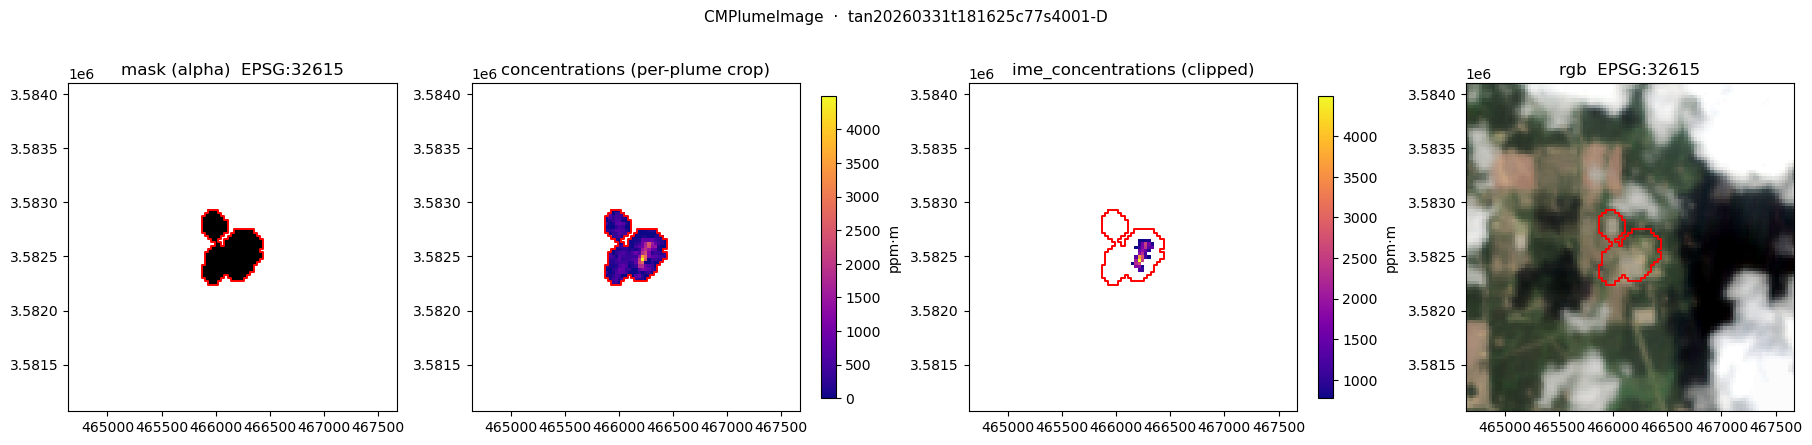

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from pyproj import Transformer
from shapely.ops import transform as shp_transform


def _plot_outline(ax, geom_4326, dst_crs):
    """Reproject outline into dst_crs and stroke it."""
    if geom_4326 is None:
        return
    tr = Transformer.from_crs("EPSG:4326", dst_crs, always_xy=True)
    g = shp_transform(tr.transform, geom_4326)
    polys = list(g.geoms) if g.geom_type == "MultiPolygon" else [g]
    for p in polys:
        x, y = p.exterior.xy
        ax.plot(x, y, color="red", lw=1.4, solid_capstyle="round")


# Pick the widest available extent (rgb is widest by CM convention)
# and lock all panels' xlim/ylim to it for visual consistency.
target_crs = None
xmin = ymin = float("inf")
xmax = ymax = float("-inf")
for reader in (img.mask, img.concentrations, img.ime_concentrations, img.rgb):
    if reader is None:
        continue
    b = reader.bounds
    target_crs = target_crs or str(reader.crs)
    xmin, ymin = min(xmin, b[0]), min(ymin, b[1])
    xmax, ymax = max(xmax, b[2]), max(ymax, b[3])
common_xlim = (xmin, xmax)
common_ylim = (ymin, ymax)


import time

# Refresh token + light throttling before the multi-raster reads
# below — the api gateway sometimes rate-limits tight read bursts.
fresh = CarbonMapperConfig.load().refresh_access_token()
import os
os.environ["GDAL_HTTP_HEADERS"] = f"Authorization: Bearer {fresh}"

fig, axes = plt.subplots(1, 4, figsize=(18, 4.6), constrained_layout=True)

# (a) mask — band 4 alpha
time.sleep(1); mask_geo = img.mask.load()
mask_arr = np.asarray(mask_geo.values)
alpha = (mask_arr[3] > 0).astype("uint8") if mask_arr.shape[0] >= 4 else mask_arr.squeeze()
bx = mask_geo.bounds
axes[0].imshow(
    alpha,
    extent=(bx[0], bx[2], bx[1], bx[3]),
    origin="upper", cmap="Greys", interpolation="nearest",
)
_plot_outline(axes[0], img.outline, str(mask_geo.crs))
axes[0].set_title(f"mask (alpha)  {mask_geo.crs}")

# (b) concentrations — full per-plume crop from plume-concentrations.tif
time.sleep(1); con_geo = img.concentrations.load()
con_arr = np.asarray(con_geo.values).squeeze().astype("float32")
nd = img.concentrations.nodata
if nd is not None:
    con_arr = np.where(con_arr == nd, np.nan, con_arr)
bx = con_geo.bounds
im = axes[1].imshow(
    con_arr,
    extent=(bx[0], bx[2], bx[1], bx[3]),
    origin="upper", cmap="plasma",
)
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label="ppm·m")
_plot_outline(axes[1], img.outline, str(con_geo.crs))
axes[1].set_title("concentrations (per-plume crop)")

# (c) IME concentrations (mask-clipped, per-plume)
if img.ime_concentrations is not None:
    time.sleep(1); ime_geo = img.ime_concentrations.load()
    ime_arr = np.asarray(ime_geo.values).squeeze().astype("float32")
    nd = img.ime_concentrations.nodata
    if nd is not None:
        ime_arr = np.where(ime_arr == nd, np.nan, ime_arr)
    bx = ime_geo.bounds
    im = axes[2].imshow(
        ime_arr,
        extent=(bx[0], bx[2], bx[1], bx[3]),
        origin="upper", cmap="plasma",
    )
    fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04, label="ppm·m")
    _plot_outline(axes[2], img.outline, str(ime_geo.crs))
    axes[2].set_title("ime_concentrations (clipped)")
else:
    axes[2].set_axis_off()
    axes[2].set_title("ime_concentrations (absent)")

# (d) RGB
if img.rgb is not None:
    time.sleep(1); rgb_geo = img.rgb.load()
    rgb_arr = np.asarray(rgb_geo.values)
    rgb_img = np.moveaxis(rgb_arr[:3], 0, -1).astype("float32")
    lo, hi = np.nanpercentile(rgb_img, [2, 98])
    rgb_img = np.clip((rgb_img - lo) / max(hi - lo, 1e-9), 0, 1)
    bx = rgb_geo.bounds
    axes[3].imshow(rgb_img, extent=(bx[0], bx[2], bx[1], bx[3]), origin="upper")
    _plot_outline(axes[3], img.outline, str(rgb_geo.crs))
    axes[3].set_title(f"rgb  {rgb_geo.crs}")
else:
    axes[3].set_axis_off()
    axes[3].set_title("rgb (absent)")

# Lock all four panels to the same viewport for direct comparison.
for ax in axes:
    ax.set_xlim(common_xlim)
    ax.set_ylim(common_ylim)
    ax.set_aspect("equal")

fig.suptitle(f"CMPlumeImage  ·  {PLUME_ID}", fontsize=11)
plt.show()


## 3 · Tiles — L2B scene rasters

`CMImageRaster` wraps the L2B retrieval scene — full Tanager swath
with `cmf` / `cmf-unortho` / `uncertainty` / `uncertainty-unortho`
/ `artifact-mask` / `uas` (text sidecar) plus an `rgb` sibling.
The per-scene products live in `DEFAULT_SCENE_PRODUCTS` and can be
sub-selected the same way as the plume bundle.

Use `api_queries.get_image_raster_for_plume(token, plume_id)` —
the canonical resolver. It fetches the plume record once, resolves
the `CMCollectionSpec`, and probes the L2B collection at the
**record's own version first** (older candidates as backup). The
protagonist showcases why the backup matters: its L3A was
re-versioned to `v3d` but the L2B parent still serves at `v3c` —
the spec probe 404s once and the candidate list catches it.
`img.tile` (used in §3.4) resolves through the same spec logic.

In [10]:
from georeader.readers.carbonmapper import CMImageRaster

# One resolver for every version. Returns a CMImageRaster with
# all 7 L2B assets (cmf, cmf-unortho, uncertainty,
# uncertainty-unortho, artifact-mask, uas, rgb sibling). Lazy:
# no rasters are opened until a property is accessed.
ir = api_queries.get_image_raster_for_plume(TOKEN, PLUME_ID)
print(ir)
print()
# URL pattern: {base}/{collection}/{Y}/{M}/{D}/{scene}/{file}
print(f"L2B collection used: {str(ir.asset_paths['cmf']).split('/')[-6]}")

CMImageRaster
  scene_id:       tan20260331t181625c77s4001
  bands present:  ['cmf', 'cmf-unortho', 'uncertainty', 'uncertainty-unortho', 'artifact-mask', 'rgb']
  extra keys:     ['uas']
  overview_level: full

L2B collection used: l2b-ch4-mfa-v3c


### 3.1.5 Cache L2B rasters locally

The v3c L2B CDN can rate-limit tight rasterio read bursts — the
demos in §§ 3.2 / 3.3 / 3.4 open `cmf` / `rgb` / `uncertainty`
multiple times each. Pre-download those three GeoTIFFs via Python
`requests` (whose 429-retry adapter we configured in the setup
cell), then rebind `ir.asset_paths` to the local files. Idempotent:
re-runs skip files already in `/tmp/cm_notebooks/<plume_id>/`.

This is purely a notebook-cell cache for repeatable demos —
`CMImageRaster` reads from whatever paths are in `asset_paths`, so
local file paths work transparently. Production code goes
straight at the CDN.


In [11]:
from pathlib import Path

import requests  # uses the retry-equipped session from the setup cell

CACHE_DIR = Path("/tmp/cm_notebooks") / PLUME_ID
CACHE_DIR.mkdir(parents=True, exist_ok=True)

for band in ("cmf", "rgb", "uncertainty"):
    url = ir.asset_paths[band]
    local = CACHE_DIR / f"{band}.tif"
    if not local.exists():
        print(f"  fetching  {band:13s} -> {local}")
        r = requests.get(
            url,
            headers={"Authorization": f"Bearer {TOKEN}"},
            stream=True,
            timeout=120,
        )
        r.raise_for_status()
        with local.open("wb") as fh:
            for chunk in r.iter_content(chunk_size=1 << 20):
                fh.write(chunk)
    else:
        print(f"  cached    {band:13s} ({local.stat().st_size // 1024:>5d} KB)")
    # Rebind so downstream rasterio reads (read_polygon, tile_*) hit
    # the local file instead of the CDN.
    ir.asset_paths[band] = str(local)

# Share the cached `ir` with CMPlumeImage's `.tile` cached_property
# so img.tile_cmf() / .tile_rgb() / .tile_uncertainty() in §3.4 also
# read from the local cache. Pre-seeding __dict__ short-circuits the
# get_image_raster_for_plume call the descriptor would otherwise make.
img.__dict__["tile"] = ir


  fetching  cmf           -> /tmp/cm_notebooks/tan20260331t181625c77s4001-D/cmf.tif


  fetching  rgb           -> /tmp/cm_notebooks/tan20260331t181625c77s4001-D/rgb.tif


  fetching  uncertainty   -> /tmp/cm_notebooks/tan20260331t181625c77s4001-D/uncertainty.tif


### 3.1 Lazy band properties

Every loadable L2B asset has a property — including the
`*-unortho` raw-frame variants and the `uas` text sidecar that
older versions of the wrapper dropped at construction. Inventory
the URLs without opening any raster (actual reads happen in
§3.3 below).


In [12]:
# Inventory the L2B assets resolved on this CMImageRaster — no
# rasterio opens here (avoids hammering the api gateway with a
# burst of HTTP heads).
for band in ("cmf", "cmf-unortho", "uncertainty", "uncertainty-unortho",
             "artifact-mask", "rgb", "uas"):
    have = band in ir.asset_paths
    print(f"  {band:24s} {'yes' if have else 'no'}")

# Scene-level metadata is stored on the wrapper itself (no IO).
print()
print(f"scene_id  : {ir.scene_id}")


  cmf                      yes
  cmf-unortho              yes
  uncertainty              yes
  uncertainty-unortho      yes
  artifact-mask            yes
  rgb                      yes
  uas                      yes

scene_id  : tan20260331t181625c77s4001


### 3.2 `read_polygon` — clip the scene to a polygon

Returns `{band: <GeoData> | None}` per requested band. Use
`img.outline` (from §2) as the clip geometry to fetch the
column-density crop straight from the parent scene — same data
Carbon Mapper duplicates as `con_tif` per plume.


In [13]:
# `read_polygon` interprets the geometry's CRS via crs_polygon.
# img.outline is in EPSG:4326 — the default.
crops = ir.read_polygon(
    polygon=img.outline,
    bands=("cmf", "uncertainty"),
)
for band, reader in crops.items():
    if reader is None:
        print(f"{band:14s}: no overlap")
    else:
        geo = reader.load()
        print(f"{band:14s}: GeoTensor shape={tuple(geo.values.shape)} crs={geo.crs}")


cmf           : GeoTensor shape=(1, 23, 19) crs=EPSG:32615
uncertainty   : GeoTensor shape=(1, 23, 19) crs=EPSG:32615


### 3.3 Visualise — scene crop with plume polygon overlay

Pad the plume bounds 4× for context, crop each band, then overlay
the plume polygon (reprojected EPSG:4326 → scene CRS) on each
panel.


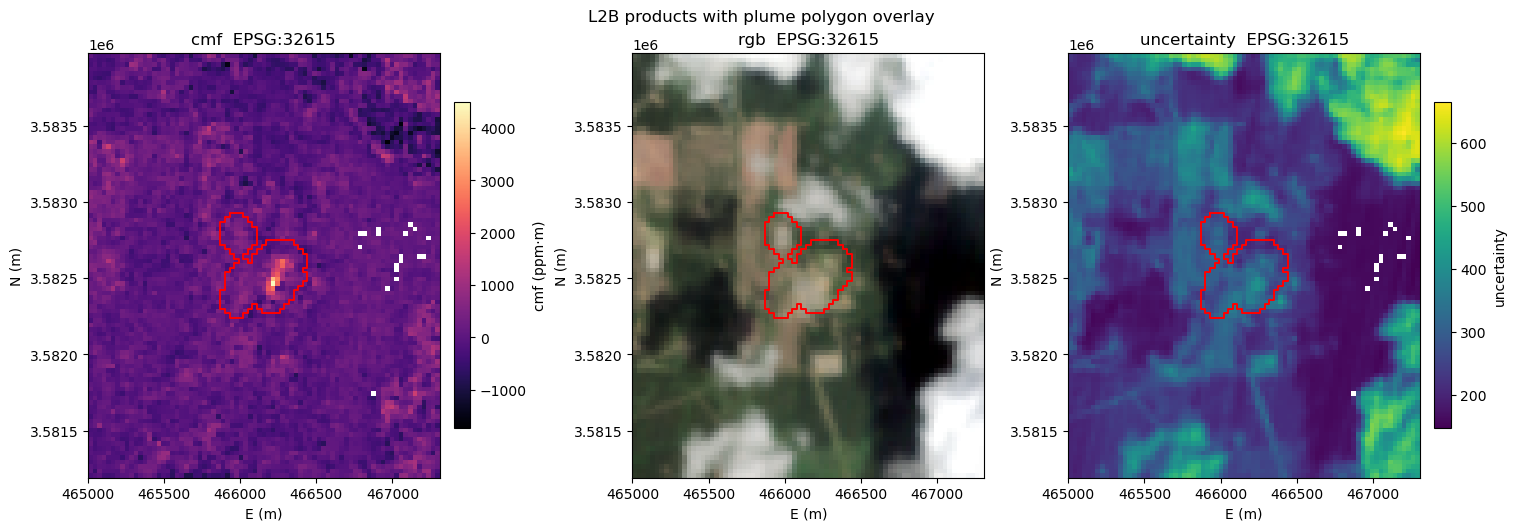

In [14]:
import shapely.affinity as saff
from shapely.geometry import box as shp_box

# 4× padded window for context.
context_window = saff.scale(shp_box(*img.outline.bounds), xfact=4.0, yfact=4.0)
context_crops = ir.read_polygon(
    polygon=context_window,
    bands=("cmf", "rgb", "uncertainty"),
)

panels = [
    ("cmf",         "magma",   "cmf (ppm·m)"),
    ("rgb",         None,      None),
    ("uncertainty", "viridis", "uncertainty"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5.2), constrained_layout=True)
for ax, (band, cmap, cbar_label) in zip(axes, panels):
    reader = context_crops[band]
    if reader is None:
        ax.set_axis_off()
        ax.set_title(f"{band} (no overlap)")
        continue
    geo = reader.load()
    arr = np.asarray(geo.values)
    bx = geo.bounds

    if band == "rgb" and arr.ndim == 3 and arr.shape[0] >= 3:
        rgb_img = np.moveaxis(arr[:3], 0, -1).astype("float32")
        lo, hi = np.nanpercentile(rgb_img, [2, 98])
        rgb_img = np.clip((rgb_img - lo) / max(hi - lo, 1e-9), 0, 1)
        ax.imshow(rgb_img, extent=(bx[0], bx[2], bx[1], bx[3]), origin="upper")
    else:
        a = arr.squeeze().astype("float32")
        nd = reader.nodata
        if nd is not None:
            a = np.where(a == nd, np.nan, a)
        im = ax.imshow(
            a, extent=(bx[0], bx[2], bx[1], bx[3]),
            origin="upper", cmap=cmap,
        )
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=cbar_label)

    _plot_outline(ax, img.outline, str(geo.crs))
    ax.set_title(f"{band}  {geo.crs}")
    ax.set_xlabel("E (m)")
    ax.set_ylabel("N (m)")
    ax.set_aspect("equal")

fig.suptitle("L2B products with plume polygon overlay")
plt.show()


### 3.4 L3A thumbnail vs L2B tile-crop — side-by-side

The L3A pre-cropped products (`plume-concentrations.tif`,
`ime-cmf-concentrations.tif`, etc.) are **thumbnail-grade** —
the IME concentration raster is typically ~11 × 11 px and
pixelates into circle-like blobs. The Phase 2 `tile_*()`
methods crop the L2B parent at full native resolution
(~150 × 150 px with the default `pad_px=64`), giving a
recognisable plume image you can actually overlay against an
RGB context.

Same plume, same outline polygon overlay — left column is the
L3A thumbnail, right column is `img.tile_*` at L2B native
resolution.

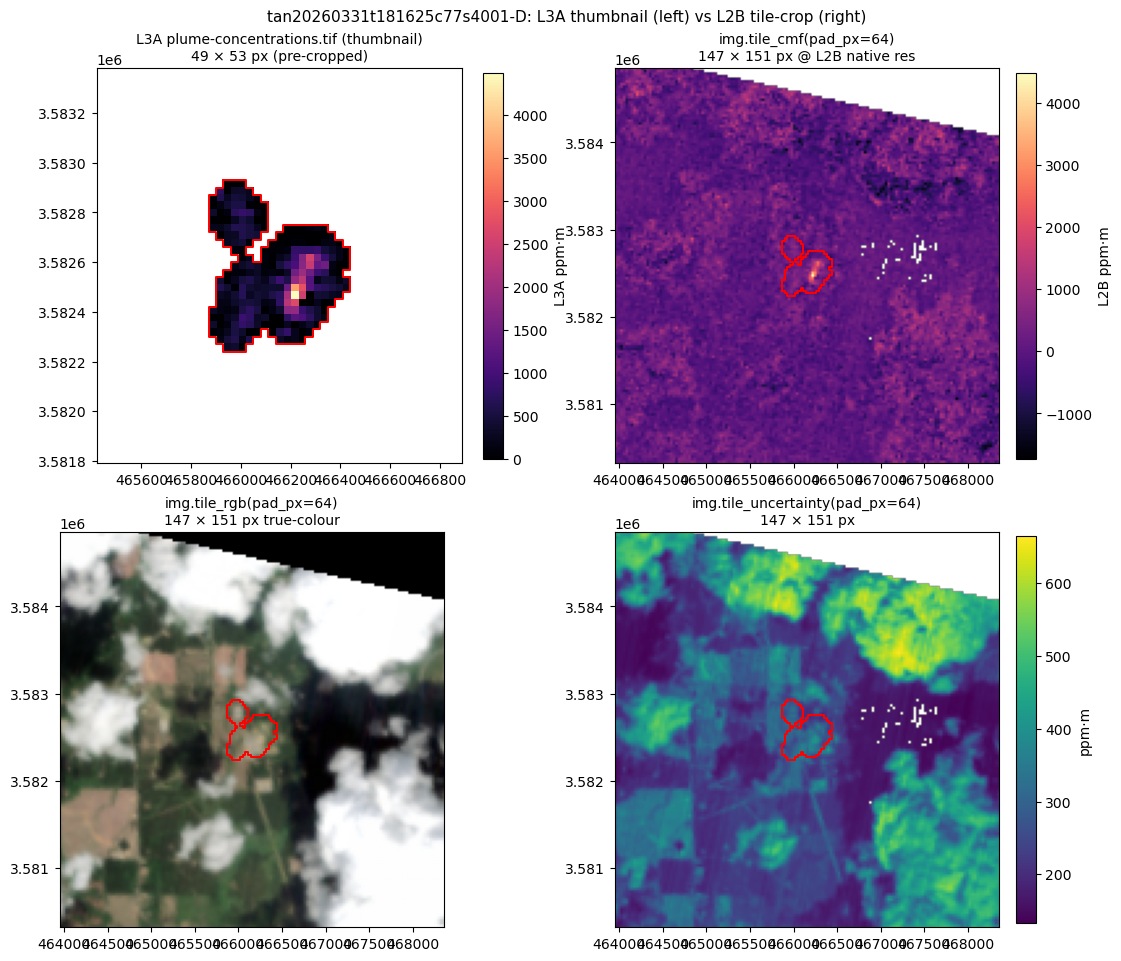

In [15]:
# Phase 2: one method call per band. .tile is lazy (one HTTP
# the first time, cached thereafter); the crop methods do
# read.read_from_polygon(...) + .load() internally.
# `img` was already constructed in §2 from the protagonist PLUME_ID.
crop_cmf = img.tile_cmf(pad_px=64)         # GeoTensor
crop_rgb = img.tile_rgb(pad_px=64)         # GeoTensor
crop_unc = img.tile_uncertainty(pad_px=64) # GeoTensor
outline_overlay = img.outline

fig, axes = plt.subplots(2, 2, figsize=(11, 9.5), constrained_layout=True)

# Top-left: L3A pre-cropped thumbnail (small, pixelated).
ax = axes[0, 0]
l3a_arr = img.concentrations.load().values.squeeze()
l3a_bounds = img.concentrations.bounds
l3a_nd = img.concentrations.nodata
if l3a_nd is not None:
    l3a_arr = np.where(l3a_arr == l3a_nd, np.nan, l3a_arr)
im0 = ax.imshow(
    l3a_arr,
    extent=(l3a_bounds[0], l3a_bounds[2], l3a_bounds[1], l3a_bounds[3]),
    origin="upper", cmap="magma",
)
fig.colorbar(im0, ax=ax, fraction=0.046, pad=0.04, label="L3A ppm·m")
ax.set_title(
    f"L3A plume-concentrations.tif (thumbnail)\n"
    f"{l3a_arr.shape[1]} × {l3a_arr.shape[0]} px (pre-cropped)",
    fontsize=10,
)
_plot_outline(ax, outline_overlay, str(img.concentrations.crs))
ax.set_aspect("equal")

# Top-right: Phase 2 .tile_cmf — L2B native resolution.
ax = axes[0, 1]
cmf_arr = np.asarray(crop_cmf.values).squeeze().astype("float32")
# Mask nodata from the cropped tile (-9999 sentinel).
cmf_arr = np.where(cmf_arr == -9999, np.nan, cmf_arr)
bx = crop_cmf.bounds
im1 = ax.imshow(
    cmf_arr, extent=(bx[0], bx[2], bx[1], bx[3]),
    origin="upper", cmap="magma",
)
fig.colorbar(im1, ax=ax, fraction=0.046, pad=0.04, label="L2B ppm·m")
ax.set_title(
    f"img.tile_cmf(pad_px=64)\n"
    f"{cmf_arr.shape[1]} × {cmf_arr.shape[0]} px @ L2B native res",
    fontsize=10,
)
_plot_outline(ax, outline_overlay, str(crop_cmf.crs))
ax.set_aspect("equal")

# Bottom-left: .tile_rgb — proper context image.
ax = axes[1, 0]
rgb_img = np.moveaxis(np.asarray(crop_rgb.values)[:3], 0, -1).astype("float32")
lo, hi = np.nanpercentile(rgb_img, [2, 98])
rgb_img = np.clip((rgb_img - lo) / max(hi - lo, 1e-9), 0, 1)
rb = crop_rgb.bounds
ax.imshow(rgb_img, extent=(rb[0], rb[2], rb[1], rb[3]), origin="upper")
ax.set_title(
    f"img.tile_rgb(pad_px=64)\n"
    f"{rgb_img.shape[1]} × {rgb_img.shape[0]} px true-colour",
    fontsize=10,
)
_plot_outline(ax, outline_overlay, str(crop_rgb.crs))
ax.set_aspect("equal")

# Bottom-right: .tile_uncertainty.
ax = axes[1, 1]
unc_arr = np.asarray(crop_unc.values).squeeze().astype("float32")
unc_arr = np.where(unc_arr == -9999, np.nan, unc_arr)
ub = crop_unc.bounds
im3 = ax.imshow(
    unc_arr, extent=(ub[0], ub[2], ub[1], ub[3]),
    origin="upper", cmap="viridis",
)
fig.colorbar(im3, ax=ax, fraction=0.046, pad=0.04, label="ppm·m")
ax.set_title(
    f"img.tile_uncertainty(pad_px=64)\n"
    f"{unc_arr.shape[1]} × {unc_arr.shape[0]} px",
    fontsize=10,
)
_plot_outline(ax, outline_overlay, str(crop_unc.crs))
ax.set_aspect("equal")

fig.suptitle(
    f"{PLUME_ID}: L3A thumbnail (left) vs L2B tile-crop (right)",
    fontsize=11,
)
plt.show()

## 4 · Sources — DBSCAN clusters with stats

`CMSource` is one DBSCAN-clustered point source, addressed by the
deterministic key `{gas}_{sector}_{footprint_m}m_{lon}_{lat}`. One
source aggregates many plumes detected at the same physical site
across many scenes / dates.

Three patterns to know:

1. **`list_sources`** — paginated source listing within a bbox.
2. **`get_source_for_plume`** — resolve plume → source.
3. **`list_plumes_for_source`** — fan out to every detection
   attributed to one source (CSV-backed; full materialisation).

Below we use pattern 2 to find our protagonist plume's source,
then pattern 3 to compute per-source detection statistics.


In [16]:
# Plume → its source (one HTTP, returns None if the plume isn't
# clustered yet — first-detection sites haven't passed DBSCAN).
src = api_queries.get_source_for_plume(TOKEN, PLUME_ID)


def _fmt(v, fmt=""):
    return f"{v:{fmt}}" if v is not None else "—"


if src is None:
    print("plume not yet clustered into a source")
else:
    print(f"source_name  : {src.source_name}")
    print(f"sector       : {src.sector or '—'}")
    print(f"plume_count  : {_fmt(src.plume_count)}")
    print(f"persistence  : {_fmt(src.persistence, '.2f')}")
    print(f"emission_auto: {_fmt(src.emission_auto, '.0f')} kg/h  (site-aggregate)")
    print(f"point        : ({src.point.x:.5f}, {src.point.y:.5f})")


source_name  : CH4_1B2_100m_-93.35926_32.37809
sector       : —
plume_count  : 0
persistence  : 0.00
emission_auto: — kg/h  (site-aggregate)
point        : (-93.35926, 32.37809)


### 4.1 All plumes attributed to a persistent source

Our protagonist plume above may or may not have been clustered
into a source yet — fresh detections usually haven't passed
DBSCAN at the time of acquisition. For the stats walkthrough,
resolve a known-persistent Permian oil-and-gas source **at run
time** (source names are re-clustered upstream, so hardcoding one
goes stale) — pick the bbox's highest `plume_count`.

`list_plumes_for_source` materialises every detection into a
list of typed `CMRawPlume`s — read from the plume records the
source detail endpoint embeds (single-shot, no pagination).


In [17]:
# Resolve the demo source at run time: the most-detected CH4 source
# in the Permian bbox. (Source names are re-clustered upstream —
# never hardcode them.)
PERMIAN_BBOX = (-104.5, 32.0, -103.5, 32.8)
permian_sources = api_queries.list_sources(TOKEN, bbox=PERMIAN_BBOX, gas="CH4")
demo_src = max(permian_sources, key=lambda s: s.plume_count or 0)
DEMO_SOURCE = demo_src.source_name
plumes_at_source = api_queries.list_plumes_for_source(TOKEN, DEMO_SOURCE)
print(f"{len(plumes_at_source)} detections at {DEMO_SOURCE}")
print()
print(f"{'plume_id':40s} {'date':10s} {'inst':5s} {'kg/h':>8s}")
print("-" * 70)
for p in plumes_at_source[:6]:
    obs = p.observation_datetime
    date = obs.date().isoformat() if obs else "—"
    em = f"{p.emission_auto:.0f}" if p.emission_auto is not None else "—"
    print(f"{p.plume_id:40s} {date:10s} {p.instrument or '—':5s} {em:>8s}")
if len(plumes_at_source) > 6:
    print(f"... and {len(plumes_at_source) - 6} more")


43 detections at CH4_1B2_250m_-104.11776_32.02621

plume_id                                 date       inst      kg/h
----------------------------------------------------------------------
ang20191006t180341-1                     2019-10-06 ang        339
ang20191010t195717-B                     2019-10-10 ang        514
ang20191011t165345-D                     2019-10-11 ang        267
ang20191016t174016-D                     2019-10-16 ang        177
ang20191017t160033-E                     2019-10-17 ang        278
ang20191019t171416-A                     2019-10-19 ang        533
... and 37 more


### 4.2 Source statistics

Compute a quick site profile from the attributed-plume list:

- detection count + distinct days
- emission distribution (median / p90 / max)
- sensor mix
- date span (first → last detection)

These are the same kinds of stats Carbon Mapper's own source UI
shows; rolling them up locally lets you filter / compare sources
yourself without the UI.


In [18]:
import pandas as pd

# Emissions: filter out the unset / hidden cases
emissions = pd.Series(
    [p.emission_auto for p in plumes_at_source if p.emission_auto is not None],
    name="kg_per_h",
)

# Distinct detection days
detection_dates = sorted({
    p.observation_datetime.date()
    for p in plumes_at_source
    if p.observation_datetime is not None
})

# Sensor mix
sensor_counts = pd.Series(
    [p.instrument for p in plumes_at_source if p.instrument]
).value_counts()


def _fmt(v, fmt=""):
    return f"{v:{fmt}}" if v is not None else "—"


# Pretty print a one-page profile
print(f"=== {demo_src.source_name} ===")
print(f"sector              : {demo_src.sector or '—'}")
print(f"persistence         : {_fmt(demo_src.persistence, '.2f')}")
print(f"site emission_auto  : {_fmt(demo_src.emission_auto, '>8.0f')} kg/h  (CM aggregate)")
print()
print(f"detections          : {len(plumes_at_source)}")
print(f"with emission       : {len(emissions)}")
print(f"distinct days       : {len(detection_dates)}")
if detection_dates:
    print(f"date range          : {detection_dates[0]}  →  {detection_dates[-1]}")
print()
if len(emissions):
    print(f"emission (kg/h):")
    print(emissions.describe(percentiles=[0.5, 0.9, 0.99]).round(0).to_string())
    print()
print(f"sensor mix:")
print(sensor_counts.to_string())


=== CH4_1B2_250m_-104.11776_32.02621 ===
sector              : 1B2
persistence         : 0.75
site emission_auto  :      245 kg/h  (CM aggregate)

detections          : 43
with emission       : 39
distinct days       : 27
date range          : 2019-10-06  →  2026-03-11

emission (kg/h):
count      39.0
mean      398.0
std       372.0
min        37.0
50%       278.0
90%       866.0
99%      1523.0
max      1640.0

sensor mix:
GAO    27
ang     9
av3     3
tan     3
emi     1


### 4.3 Visualise — emission timeline

A scatter of every detection's emission rate over time, with the
site-aggregate `emission_auto` from the `CMSource` overlaid.
Helps you eyeball whether the source's headline emission rate is
representative of typical detections, or skewed by a few
super-emitter days.


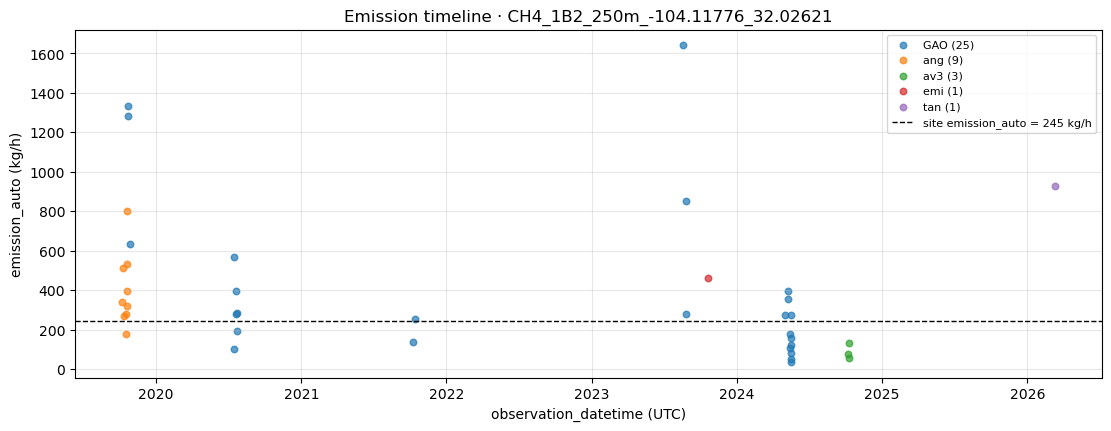

In [19]:
detections_df = pd.DataFrame([
    {
        "datetime": p.observation_datetime,
        "emission_auto": p.emission_auto,
        "instrument": p.instrument,
    }
    for p in plumes_at_source
    if p.observation_datetime is not None
       and p.emission_auto is not None
]).sort_values("datetime")

if len(detections_df) == 0:
    print("no detections with emissions to plot")
else:
    fig, ax = plt.subplots(figsize=(11, 4.2), constrained_layout=True)
    for inst, subset in detections_df.groupby("instrument"):
        ax.scatter(
            subset["datetime"], subset["emission_auto"],
            label=f"{inst} ({len(subset)})", alpha=0.7, s=22,
        )
    if demo_src.emission_auto is not None:
        ax.axhline(
            demo_src.emission_auto, color="black", linestyle="--", linewidth=1,
            label=f"site emission_auto = {demo_src.emission_auto:.0f} kg/h",
        )
    ax.set_xlabel("observation_datetime (UTC)")
    ax.set_ylabel("emission_auto (kg/h)")
    ax.set_title(f"Emission timeline · {demo_src.source_name}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.show()


## See also

- [`api_explore.ipynb`](api_explore.ipynb) — the typed query layer
  in depth (REST + STAC surfaces, filter map, exception
  hierarchy, plume catalog stats).
- [Carbon Mapper Reader API reference](../modules/readers_module.md#carbon-mapper-reader)
  — full module / class / function listing.
- [GeoReader concepts](../modules/read_module.md) — the abstract
  `GeoData` protocol both `RasterioReader` and `GeoTensor` satisfy.
